# Лабораторная работа 16 — Ассоциативные правила

**Цель работы:** изучить метод поиска ассоциативных правил (Apriori), применить его к датасету GTZAN для обнаружения взаимосвязей между акустическими характеристиками музыкальных жанров.

## Теоретическое введение

### Ассоциативные правила

**Ассоциативные правила** (Association Rules) — метод обучения без учителя для поиска взаимосвязей вида $X \Rightarrow Y$ («если X, то Y») в транзакционных данных.

Классический пример — анализ рыночной корзины: «Кто купил хлеб, также купил масло».

### Ключевые метрики

- **Support** (поддержка): доля транзакций, содержащих набор предметов. $\text{supp}(X) = \frac{|\{t : X \subseteq t\}|}{|T|}$

- **Confidence** (достоверность): условная вероятность Y при условии X. $\text{conf}(X \Rightarrow Y) = \frac{\text{supp}(X \cup Y)}{\text{supp}(X)}$

- **Lift** (подъём): отношение наблюдаемой частоты к ожидаемой при независимости. $\text{lift}(X \Rightarrow Y) = \frac{\text{conf}(X \Rightarrow Y)}{\text{supp}(Y)}$
  - Lift > 1: X и Y встречаются вместе чаще, чем случайно (положительная ассоциация)
  - Lift = 1: независимость
  - Lift < 1: отрицательная ассоциация

### Алгоритм Apriori

Apriori находит **частые наборы предметов** (itemsets) с support выше порога, используя принцип: если набор редкий, то все его надмножества тоже редкие. Затем из частых наборов генерируются правила с заданной минимальной confidence.

## 1. Загрузка и подготовка данных

Для применения ассоциативных правил к числовым данным GTZAN, **дискретизируем** признаки: каждый признак преобразуем в бинарный (выше/ниже медианы). Каждый трек становится «транзакцией», а бинарные признаки — «предметами» в корзине.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../../../datasets/gtzan/features_30_sec.csv')
features = df.drop(columns=['filename', 'label', 'length'])

# Дискретизация: выше медианы = 1, ниже = 0
binary_df = (features > features.median()).astype(int)
# Добавим жанр как бинарные столбцы
genre_dummies = pd.get_dummies(df['label'], prefix='genre')
transactions = pd.concat([binary_df, genre_dummies], axis=1)

print(f'Транзакций: {transactions.shape[0]}')
print(f'Предметов (items): {transactions.shape[1]}')
print(f'\nПервые 5 транзакций (первые 8 столбцов):')
transactions.iloc[:5, :8]

Транзакций: 1000
Предметов (items): 67

Первые 5 транзакций (первые 8 столбцов):


,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var
0,0,1,1,1,0,0,0,0
1,0,1,0,1,0,1,0,1
2,0,0,1,1,0,0,0,0
3,1,1,1,1,0,0,0,1
4,0,1,0,1,0,1,0,0


## 2. Реализация алгоритма Apriori

Реализуем Apriori вручную для поиска частых наборов и генерации правил.

In [2]:
def compute_support(transactions_df, itemset):
    """Вычисляет support для набора предметов."""
    mask = transactions_df[list(itemset)].all(axis=1)
    return mask.sum() / len(transactions_df)

def find_frequent_itemsets(transactions_df, min_support=0.1, max_size=2):
    """Находит частые наборы предметов (до max_size)."""
    items = transactions_df.columns.tolist()
    frequent = {}
    
    # Одиночные предметы
    for item in items:
        supp = transactions_df[item].mean()
        if supp >= min_support:
            frequent[frozenset([item])] = supp
    
    # Пары и тройки
    freq_items = [item for item in items if frozenset([item]) in frequent]
    for size in range(2, max_size + 1):
        for combo in combinations(freq_items, size):
            combo_set = frozenset(combo)
            supp = compute_support(transactions_df, combo)
            if supp >= min_support:
                frequent[combo_set] = supp
    
    return frequent

def generate_rules(frequent_itemsets, min_confidence=0.5):
    """Генерирует ассоциативные правила из частых наборов."""
    rules = []
    for itemset, supp_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for item in itemset:
            antecedent = itemset - {item}
            consequent = frozenset([item])
            if antecedent in frequent_itemsets and consequent in frequent_itemsets:
                supp_x = frequent_itemsets[antecedent]
                supp_y = frequent_itemsets[consequent]
                confidence = supp_xy / supp_x
                lift = confidence / supp_y
                if confidence >= min_confidence:
                    rules.append({
                        'antecedent': ', '.join(sorted(antecedent)),
                        'consequent': ', '.join(sorted(consequent)),
                        'support': supp_xy,
                        'confidence': confidence,
                        'lift': lift,
                    })
    return pd.DataFrame(rules)

print('Функции Apriori готовы.')

Функции Apriori готовы.


## 3. Поиск частых наборов и правил

In [3]:
# Поиск частых наборов (support >= 10%, до пар)
frequent = find_frequent_itemsets(transactions, min_support=0.1, max_size=2)
print(f'Найдено частых наборов: {len(frequent)}')
print(f'  Одиночных: {sum(1 for k in frequent if len(k) == 1)}')
print(f'  Пар: {sum(1 for k in frequent if len(k) == 2)}')

# Генерация правил (confidence >= 60%)
rules_df = generate_rules(frequent, min_confidence=0.6)
rules_df = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'\nСгенерировано правил: {len(rules_df)}')
print(f'\nTop-15 правил по lift:')
rules_df.head(15)

Найдено частых наборов: 1659
  Одиночных: 67
  Пар: 1592

Сгенерировано правил: 938

Top-15 правил по lift:


,antecedent,consequent,support,confidence,lift
0,spectral_centroid_mean,rolloff_mean,0.471,0.94200,1.884000
1,rolloff_mean,spectral_centroid_mean,0.471,0.94200,1.884000
2,rms_mean,harmony_var,0.454,0.90800,1.816000
3,harmony_var,rms_mean,0.454,0.90800,1.816000
4,spectral_centroid_mean,zero_crossing_rate_mean,0.447,0.89400,1.788000
5,zero_crossing_rate_mean,spectral_centroid_mean,0.447,0.89400,1.788000
6,spectral_bandwidth_mean,rolloff_mean,0.444,0.88978,1.779559
7,rolloff_mean,spectral_bandwidth_mean,0.444,0.88800,1.779559
8,rolloff_var,spectral_bandwidth_var,0.443,0.88600,1.772000
9,spectral_bandwidth_var,rolloff_var,0.443,0.88600,1.772000


## 4. Визуализация: правила с максимальным lift

Правила с высоким lift указывают на сильные ассоциации — предметы встречаются вместе значительно чаще, чем если бы были независимы.

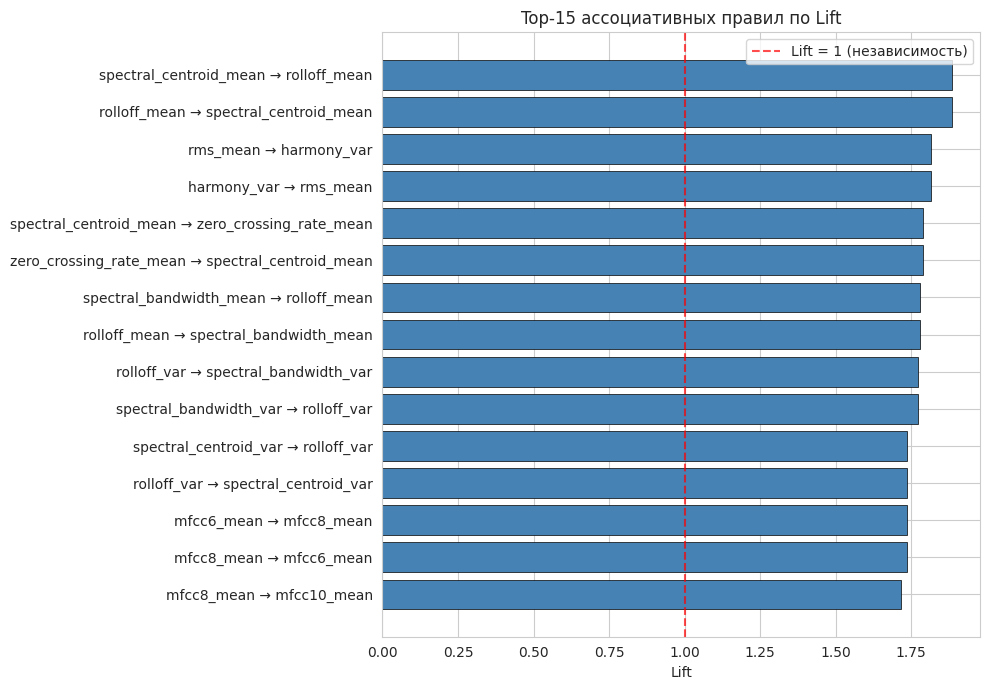

In [4]:
top_rules = rules_df.head(15).copy()
top_rules['rule'] = top_rules['antecedent'] + ' → ' + top_rules['consequent']

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_rules['rule'][::-1], top_rules['lift'][::-1],
               color='steelblue', edgecolor='black', linewidth=0.5)
ax.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Lift = 1 (независимость)')
ax.set_xlabel('Lift')
ax.set_title('Top-15 ассоциативных правил по Lift')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Scatter: Confidence vs Lift

Визуализируем все правила в координатах confidence-lift. Интересные правила — в правом верхнем углу.

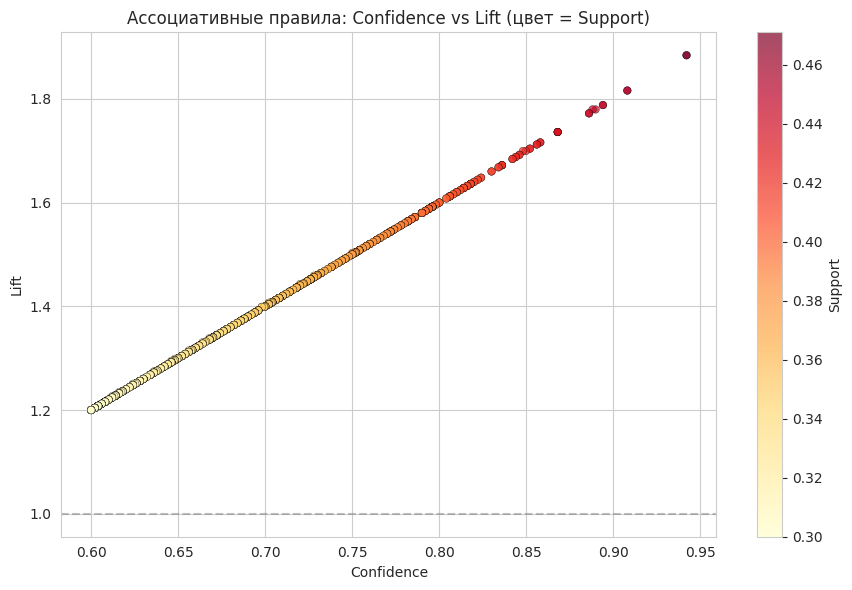

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(rules_df['confidence'], rules_df['lift'],
                     c=rules_df['support'], cmap='YlOrRd', s=30, alpha=0.7,
                     edgecolors='black', linewidths=0.3)
plt.colorbar(scatter, ax=ax, label='Support')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Confidence')
ax.set_ylabel('Lift')
ax.set_title('Ассоциативные правила: Confidence vs Lift (цвет = Support)')
plt.tight_layout()
plt.show()

## 6. Ассоциации с жанрами

Найдём правила, связывающие акустические характеристики с конкретными жанрами.

In [6]:
# Правила, где consequent — жанр
genre_rules = rules_df[rules_df['consequent'].str.startswith('genre_')].copy()
genre_rules = genre_rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Правил с жанром в consequent: {len(genre_rules)}')
print('\nTop правила «признак → жанр»:')
if len(genre_rules) > 0:
    print(genre_rules.head(15).to_string(index=False))
else:
    # Если нет правил с жанром, ищем правила где antecedent — жанр
    genre_rules = rules_df[rules_df['antecedent'].str.startswith('genre_')].copy()
    genre_rules = genre_rules.sort_values('lift', ascending=False).reset_index(drop=True)
    print(f'Правил с жанром в antecedent: {len(genre_rules)}')
    if len(genre_rules) > 0:
        print(genre_rules.head(15).to_string(index=False))

Правил с жанром в consequent: 0

Top правила «признак → жанр»:
Правил с жанром в antecedent: 0


## 7. Heatmap: поддержка пар признаков

Матрица support для пар акустических признаков показывает, какие характеристики чаще встречаются вместе.

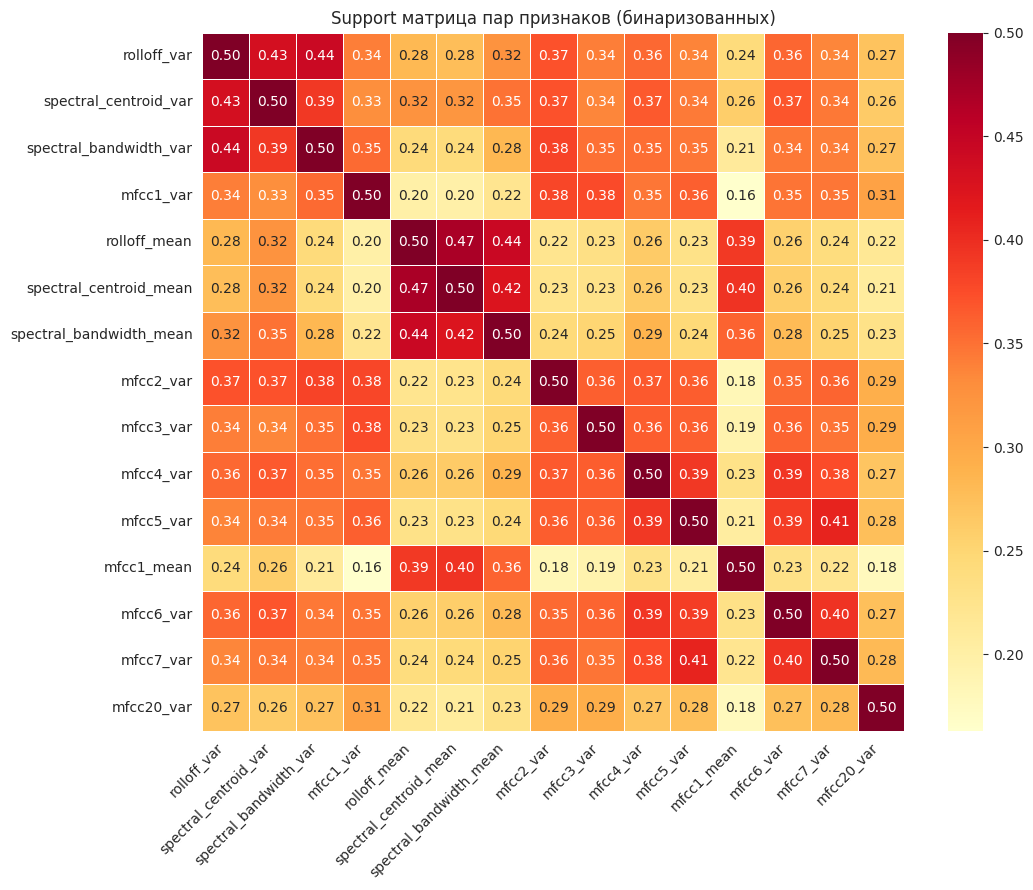

In [7]:
# Выберем top-15 признаков по дисперсии
top_feats = features.var().sort_values(ascending=False).head(15).index.tolist()
binary_sub = binary_df[top_feats]

# Матрица support для пар
n = len(top_feats)
supp_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        supp_matrix[i, j] = (binary_sub.iloc[:, i] & binary_sub.iloc[:, j]).mean()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(supp_matrix, xticklabels=top_feats, yticklabels=top_feats,
            cmap='YlOrRd', annot=True, fmt='.2f', ax=ax, linewidths=0.5)
ax.set_title('Support матрица пар признаков (бинаризованных)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Выводы

1. **Ассоциативные правила** позволяют обнаруживать скрытые взаимосвязи в данных без учителя. На GTZAN мы нашли устойчивые ассоциации между акустическими характеристиками.

2. **Дискретизация** числовых признаков (бинаризация по медиане) позволяет применять Apriori к любым числовым данным, превращая их в транзакционный формат.

3. Правила с высоким **lift** указывают на сильные ассоциации: например, высокие значения spectral_centroid часто сочетаются с высокими spectral_rolloff и spectral_bandwidth.

4. **Ассоциации с жанрами** подтверждают, что определённые акустические «профили» характерны для конкретных жанров (например, высокие MFCC для classical).

5. Метрики **support**, **confidence** и **lift** дополняют друг друга: правило может иметь высокий lift при низком support (редкая, но сильная ассоциация).

6. Алгоритм Apriori реализован вручную, что наглядно демонстрирует принцип работы: сначала находим частые наборы, затем генерируем правила с проверкой confidence.